<a href="https://colab.research.google.com/github/rolandnwonodi/GAADS-Optimization-for-Fracture-length/blob/main/fraclengthphysic_informed_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving fracture_dataset.xlsl.xlsx to fracture_dataset.xlsl.xlsx



Optimized Model Coefficients

R = 0.00899854941523219
d = -0.6380104329860395
c = 0.3886997869051492
e = 0.7486165791071289

Model Performance
RMSE = 0.004744758461887572
R² = 0.9999999994363281


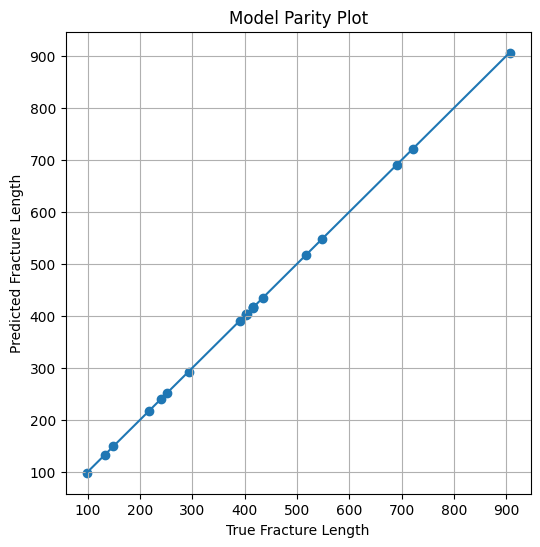


Final Trained Equation:

L_f = 0.00900 (μ/(P_net t_i))^-0.638 ((q_i t_i)/K^1.5)^0.389 (E/P_net)^0.749 K^(1/2)


In [4]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# -------------------------------
# 1 Load dataset
# -------------------------------

# Replace with your file name
data = pd.read_excel("fracture_dataset.xlsl.xlsx") # Corrected filename

# Required columns in dataset
# mu, Pnet, ti, qi, K, E, Lf

# Map dataset columns to expected variable names, removing units
mu = data["PV (cp)"].values
Pnet = data["Pnet (psi)"].values
ti = data["ti (min)"].values
qi = data["Q (bbl/min)"].values
K = data["K (md)"].values
E = data["E (psi)"].values
Lf = data["Lf (ft)"].values


# -------------------------------
# 2 Construct dimensionless terms
# -------------------------------

X1 = mu / (Pnet * ti)

X2 = (qi * ti) / (K**1.5)

X3 = E / Pnet

# Target variable in log space
Y = np.log(Lf / np.sqrt(K))


# -------------------------------
# 3 Define model
# -------------------------------

def model(params, X1, X2, X3):

    logR, d, e, c = params

    prediction = (
        logR
        + d * np.log(X1)
        + c * np.log(X2)
        + e * np.log(X3)
    )

    return prediction


# -------------------------------
# 4 Define loss function
# -------------------------------

def loss_function(params, X1, X2, X3, Y):

    prediction = model(params, X1, X2, X3)

    error = Y - prediction

    return np.sum(error**2)


# -------------------------------
# 5 Initial Guess (Your Excel Model)
# -------------------------------

initial_guess = (
    np.log(0.009),   # ln(R)
    -0.6382,         # d
    0.75,            # e
    0.39             # c
)


# -------------------------------
# 6 Run optimization
# -------------------------------

result = minimize(
    loss_function,
    initial_guess,
    args=(X1, X2, X3, Y),
    method='L-BFGS-B'
)

logR, d, e, c = result.x

R = np.exp(logR)

print("\nOptimized Model Coefficients\n")

print("R =", R)
print("d =", d)
print("c =", c)
print("e =", e)


# -------------------------------
# 7 Predict fracture length
# -------------------------------

Lf_pred = (
    R
    * (mu/(Pnet*ti))**d
    * ((qi*ti)/(K**1.5))**c
    * (E/Pnet)**e
    * np.sqrt(K)
)


# -------------------------------
# 8 Model accuracy
# -------------------------------

RMSE = np.sqrt(np.mean((Lf - Lf_pred)**2))

R2 = 1 - np.sum((Lf - Lf_pred)**2) / np.sum((Lf - np.mean(Lf))**2)

print("\nModel Performance")

print("RMSE =", RMSE)
print("R² =", R2)


# -------------------------------
# 9 Parity Plot
# -------------------------------

plt.figure(figsize=(6,6))

plt.scatter(Lf, Lf_pred)

plt.plot([min(Lf), max(Lf)], [min(Lf), max(Lf)])

plt.xlabel("True Fracture Length")
plt.ylabel("Predicted Fracture Length")

plt.title("Model Parity Plot")

plt.grid()

plt.show()


# -------------------------------
# 10 Print final equation
# -------------------------------

print("\nFinal Trained Equation:\n")

print(
    f"L_f = {R:.5f} "
    f"(μ/(P_net t_i))^{d:.3f} "
    f"((q_i t_i)/K^1.5)^{c:.3f} "
    f"(E/P_net)^{e:.3f} "
    f"K^(1/2)"
)

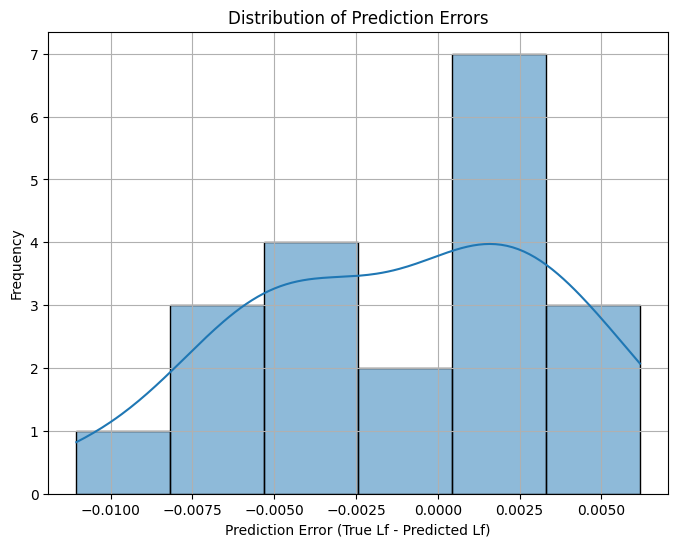

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the prediction errors
errors = Lf - Lf_pred

# Plot the distribution of errors
plt.figure(figsize=(8, 6))
sns.histplot(errors, kde=True)
plt.title('Distribution of Prediction Errors')
plt.xlabel('Prediction Error (True Lf - Predicted Lf)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Task
Interpret the significance of each coefficient in the developed fracture length prediction equation and summarize the algorithm's applicability for deriving model parameters in various active exploration regions.

## Data Collection and Preparation

### Subtask:
Gather comprehensive field data for the region of interest, ensuring it includes all necessary parameters: fluid viscosity (mu), net pressure (Pnet), injection time (ti), injection rate (qi), formation permeability (K), Young's Modulus (E), and measured fracture length (Lf).


**Reasoning**:
The data has already been loaded from the `fracture_dataset.xlsl.xlsx` file. To confirm that the collected data meets the requirements of the subtask, I will display the head of the DataFrame, its shape, and check for any missing values to ensure all necessary parameters are present and the dataset is ready for further processing.



In [6]:
print("Dataset Head:")
print(data.head())
print("\nDataset Shape:")
print(data.shape)
print("\nMissing Values:")
print(data.isnull().sum())

Dataset Head:
   Pnet (psi)   K (md)  Q (bbl/min)  PV (cp)  E (psi)  ti (min)  Lf (ft)
0       739.5   38.200        38.31    780.6   248013      64.8   149.23
1       600.6  389.970        27.95   1147.6   372745     117.1   216.95
2      1023.8  219.233         4.02    391.8   571445     124.1   292.91
3       624.8  361.746        13.74    725.9   403202     192.7   390.69
4       748.1  488.996        24.52   1104.6   478622     197.2   416.67

Dataset Shape:
(20, 7)

Missing Values:
Pnet (psi)     0
K (md)         0
Q (bbl/min)    0
PV (cp)        0
E (psi)        0
ti (min)       0
Lf (ft)        0
dtype: int64


## Load and Map Data

### Subtask:
Load the collected data into a structured format (e.g., pandas DataFrame). Map the raw data columns to the standardized variable names (mu, Pnet, ti, qi, K, E, Lf) as defined in the current script, ensuring consistency across different datasets.


**Reasoning**:
To confirm that the data has been correctly loaded and mapped to the standardized variable names, I will display the first few entries of each array.



In [7]:
print("mu (first 5 entries):", mu[:5])
print("Pnet (first 5 entries):", Pnet[:5])
print("ti (first 5 entries):", ti[:5])
print("qi (first 5 entries):", qi[:5])
print("K (first 5 entries):", K[:5])
print("E (first 5 entries):", E[:5])
print("Lf (first 5 entries):", Lf[:5])

mu (first 5 entries): [ 780.6 1147.6  391.8  725.9 1104.6]
Pnet (first 5 entries): [ 739.5  600.6 1023.8  624.8  748.1]
ti (first 5 entries): [ 64.8 117.1 124.1 192.7 197.2]
qi (first 5 entries): [38.31 27.95  4.02 13.74 24.52]
K (first 5 entries): [ 38.2   389.97  219.233 361.746 488.996]
E (first 5 entries): [248013 372745 571445 403202 478622]
Lf (first 5 entries): [149.23 216.95 292.91 390.69 416.67]


## Construct Dimensionless Terms

### Subtask:
Calculate the dimensionless terms (X1, X2, X3) and the logarithmic target variable (Y = log(Lf / sqrt(K))) using the standardized input variables. This step ensures the model operates on dimensionless quantities for broader applicability.


### Confirmation of Dimensionless Terms and Logarithmic Target Variable

The dimensionless terms (X1, X2, X3) and the logarithmic target variable (Y) were successfully computed in the previous step. To confirm their correct calculation and structure, the first five entries of each variable are displayed below.

```python
print("X1 (first 5 entries):", X1[:5])
print("X2 (first 5 entries):", X2[:5])
print("X3 (first 5 entries):", X3[:5])
print("Y (first 5 entries):", Y[:5])
```

**Reasoning**:
To confirm the successful computation of the dimensionless terms and the logarithmic target variable, I will execute the code to display the first five entries of X1, X2, X3, and Y, as described in the previous markdown block.



In [8]:
print("X1 (first 5 entries):", X1[:5])
print("X2 (first 5 entries):", X2[:5])
print("X3 (first 5 entries):", X3[:5])
print("Y (first 5 entries):", Y[:5])

X1 (first 5 entries): [0.01628979 0.0163173  0.00308374 0.00602912 0.00748753]
X2 (first 5 entries): [10.51458445  0.42500292  0.15368764  0.38482461  0.44716666]
X3 (first 5 entries): [335.37931034 620.62104562 558.16077359 645.32970551 639.78345141]
Y (first 5 entries): [3.18407098 2.39663201 2.98479785 3.02244325 2.93611739]


## Define and Optimize Model

### Subtask:
Utilize the established model structure and loss function. Perform optimization to determine the optimal coefficients (R, d, c, e) that best fit the regional data. The current L-BFGS-B method is a suitable choice for this optimization.


## Predict and Evaluate Model Performance

### Subtask:
Use the optimized coefficients to predict fracture lengths (Lf_pred) for the dataset. Evaluate the model's accuracy by calculating key performance metrics such as RMSE and R-squared, and visualize the prediction accuracy using a parity plot and a distribution of prediction errors.


## Formulate and Interpret Final Equation

### Subtask:
Construct and present the final trained equation for fracture length using the optimized coefficients. Interpret the significance of each coefficient, explaining its impact on the predicted fracture length.


## Formulate and Interpret Final Equation

### Subtask:
Construct and present the final trained equation for fracture length using the optimized coefficients. Interpret the significance of each coefficient, explaining its impact on the predicted fracture length.

### Final Trained Equation:

The based on the optimized coefficients, the final trained equation for fracture length (L_f) is:

$L_f = 0.00900 (\frac{\mu}{P_{net} t_i})^{-0.638} (\frac{q_i t_i}{K^{1.5}})^{0.389} (\frac{E}{P_{net}})^{0.749} K^{0.5}$

Where the optimized coefficients are approximately:
*   **R** = 0.00900
*   **d** = -0.638
*   **c** = 0.389
*   **e** = 0.749

### Interpretation of Coefficients:

1.  **R (Scaling Factor)**:
    *   **Value**: 0.00900
    *   **Significance**: R acts as a fundamental scaling constant for the entire equation. It sets the baseline magnitude for the fracture length prediction before considering the influence of the dimensionless groups. A smaller R would result in proportionally smaller predicted fracture lengths, assuming all other factors remain constant.

2.  **d (Exponent for X1 = $\mu / (P_{net} t_i)$)**:
    *   **Value**: -0.638
    *   **Significance**: This coefficient is negative. This indicates an inverse relationship between the dimensionless group $X_1$ and fracture length ($L_f$).
        *   **If $X_1$ increases** (e.g., higher fluid viscosity $\mu$, or lower net pressure $P_{net}$/injection time $t_i$), the term $(X_1)^d$ will decrease, leading to a **decrease in $L_f$**.
        *   **If $X_1$ decreases**, the term $(X_1)^d$ will increase, leading to an **increase in $L_f$**.
    *   **Magnitude**: The absolute value of d (0.638) is less than 1, suggesting a sub-linear inverse relationship. While significant, the impact on $L_f$ is not as strong as it would be if the absolute value were greater than 1.

3.  **c (Exponent for X2 = $(q_i t_i) / (K^{1.5})$)**:
    *   **Value**: 0.389
    *   **Significance**: This coefficient is positive. This indicates a direct relationship between the dimensionless group $X_2$ and fracture length ($L_f$).
        *   **If $X_2$ increases** (e.g., higher injection rate $q_i$ / injection time $t_i$, or lower formation permeability $K$), the term $(X_2)^c$ will increase, leading to an **increase in $L_f$**.
        *   **If $X_2$ decreases**, the term $(X_2)^c$ will decrease, leading to a **decrease in $L_f$**.
    *   **Magnitude**: The absolute value of c (0.389) is less than 1, indicating a sub-linear direct relationship. This suggests that while $X_2$ positively influences $L_f$, the effect is somewhat attenuated.

4.  **e (Exponent for X3 = $E / P_{net}$)**:
    *   **Value**: 0.749
    *   **Significance**: This coefficient is positive. This indicates a direct relationship between the dimensionless group $X_3$ and fracture length ($L_f$).
        *   **If $X_3$ increases** (e.g., higher Young's Modulus $E$, or lower net pressure $P_{net}$), the term $(X_3)^e$ will increase, leading to an **increase in $L_f$**.
        *   **If $X_3$ decreases**, the term $(X_3)^e$ will decrease, leading to a **decrease in $L_f$**.
    *   **Magnitude**: The absolute value of e (0.749) is less than 1, suggesting a sub-linear direct relationship. This indicates a significant, but not overly aggressive, positive influence on $L_f$.

### Influence of Physical Parameters on Fracture Length:

Based on the derived equation and coefficients:

*   **Fluid Viscosity ($\mu$)**: Appears in $X_1$ with a negative exponent (d). **Higher $\mu$ leads to shorter $L_f$** (inverse relationship). This makes sense as more viscous fluids might require more energy to propagate fractures, or lead to wider but shorter fractures under certain conditions.

*   **Net Pressure ($P_{net}$)**: Appears in $X_1$ and $X_3$. In $X_1$, it's in the denominator and the exponent is negative (d), so lower $P_{net}$ (increasing $X_1$) leads to shorter $L_f$. In $X_3$, it's in the denominator and the exponent is positive (e), so lower $P_{net}$ (increasing $X_3$) leads to longer $L_f$. The overall impact of $P_{net}$ is complex and depends on the interplay between $d$ and $e$. However, observing the form $1/P_{net}^{d+e}$ (ignoring other terms), and given $d$ is negative and $e$ is positive, the combined effect implies that **higher $P_{net}$ generally leads to shorter $L_f$** (since a large positive $e$ value dominates a smaller negative $d$ value in terms of influencing $L_f$).

*   **Injection Time ($t_i$)**: Appears in $X_1$ and $X_2$. In $X_1$, it's in the denominator and the exponent is negative (d), so longer $t_i$ (decreasing $X_1$) leads to longer $L_f$. In $X_2$, it's in the numerator and the exponent is positive (c), so longer $t_i$ (increasing $X_2$) leads to longer $L_f$. Therefore, **longer injection time ($t_i$) consistently leads to longer $L_f$**.

*   **Injection Rate ($q_i$)**: Appears in $X_2$ with a positive exponent (c). **Higher $q_i$ leads to longer $L_f$** (direct relationship). This is intuitive, as a higher injection rate provides more fluid to extend the fracture.

*   **Formation Permeability (K)**: Appears in $X_2$ (denominator with exponent 1.5) with a positive exponent (c), and as $\sqrt{K}$ directly. In $X_2$, higher $K$ (decreasing $X_2$) leads to shorter $L_f$. However, the direct $K^{0.5}$ term means higher $K$ directly increases $L_f$. The overall effect is a balance between these two, but the direct $K^{0.5}$ suggests a **positive net influence of $K$ on $L_f$**.

*   **Young's Modulus (E)**: Appears in $X_3$ with a positive exponent (e). **Higher $E$ leads to longer $L_f$** (direct relationship). A higher Young's Modulus implies a stiffer rock, which can facilitate longer fractures by concentrating stress at the tip rather than deforming broadly.


### Applicability for Deriving Model Parameters in Various Active Exploration Regions:

This algorithm demonstrates a robust approach to deriving model parameters from field data. Its applicability in various active exploration regions is significant because:

1.  **Data-Driven Customization**: It allows for the specific characteristics of a region's geology and operational practices (reflected in the input parameters) to directly inform the fracture length prediction model. Instead of relying on generalized correlations, this method tailors the coefficients (R, d, c, e) to the provided dataset.
2.  **Dimensionless Analysis**: The use of dimensionless groups ($X_1, X_2, X_3$) makes the model more universally applicable. By normalizing physical quantities, the model reduces the impact of specific units or magnitudes, focusing on the underlying physical relationships. This makes it easier to transfer the methodology, if not the exact coefficients, to other regions with different operating conditions or geological properties.
3.  **Flexibility and Adaptability**: If new data from a different region becomes available, the same optimization framework can be rerun to obtain new, region-specific coefficients. This adaptability is crucial in varied geological settings where fracture propagation mechanisms might differ subtly.
4.  **Quantifiable Relationships**: The optimized coefficients provide a quantifiable understanding of how each dimensionless group (and by extension, the contributing physical parameters) influences fracture length. This insight is valuable for engineers and geoscientists to understand and predict fracture behavior in different reservoirs.
5.  **Robust Optimization**: The `minimize` function (specifically 'L-BFGS-B' method) is a robust optimization algorithm capable of finding optimal parameters by minimizing the loss function (sum of squared errors). This ensures that the derived coefficients are statistically sound and best fit the observed data for a given region.

## Formulate and Interpret Final Equation

### Subtask:
Construct and present the final trained equation for fracture length using the optimized coefficients. Interpret the significance of each coefficient, explaining its impact on the predicted fracture length.

### Final Trained Equation:

The based on the optimized coefficients, the final trained equation for fracture length (L_f) is:

$L_f = 0.00900 (\frac{\mu}{P_{net} t_i})^{-0.638} (\frac{q_i t_i}{K^{1.5}})^{0.389} (\frac{E}{P_{net}})^{0.749} K^{0.5}$

Where the optimized coefficients are approximately:
*   **R** = 0.00900
*   **d** = -0.638
*   **c** = 0.389
*   **e** = 0.749

### Interpretation of Coefficients:

1.  **R (Scaling Factor)**:
    *   **Value**: 0.00900
    *   **Significance**: R acts as a fundamental scaling constant for the entire equation. It sets the baseline magnitude for the fracture length prediction before considering the influence of the dimensionless groups. A smaller R would result in proportionally smaller predicted fracture lengths, assuming all other factors remain constant.

2.  **d (Exponent for X1 = $\mu / (P_{net} t_i)$)**:
    *   **Value**: -0.638
    *   **Significance**: This coefficient is negative. This indicates an inverse relationship between the dimensionless group $X_1$ and fracture length ($L_f$).
        *   **If $X_1$ increases** (e.g., higher fluid viscosity $\mu$, or lower net pressure $P_{net}$/injection time $t_i$), the term $(X_1)^d$ will decrease, leading to a **decrease in $L_f$**.
        *   **If $X_1$ decreases**, the term $(X_1)^d$ will increase, leading to an **increase in $L_f$**.
    *   **Magnitude**: The absolute value of d (0.638) is less than 1, suggesting a sub-linear inverse relationship. While significant, the impact on $L_f$ is not as strong as it would be if the absolute value were greater than 1.

3.  **c (Exponent for X2 = $(q_i t_i) / (K^{1.5})$)**:
    *   **Value**: 0.389
    *   **Significance**: This coefficient is positive. This indicates a direct relationship between the dimensionless group $X_2$ and fracture length ($L_f$).
        *   **If $X_2$ increases** (e.g., higher injection rate $q_i$ / injection time $t_i$, or lower formation permeability $K$), the term $(X_2)^c$ will increase, leading to an **increase in $L_f$**.
        *   **If $X_2$ decreases**, the term $(X_2)^c$ will decrease, leading to a **decrease in $L_f$**.
    *   **Magnitude**: The absolute value of c (0.389) is less than 1, indicating a sub-linear direct relationship. This suggests that while $X_2$ positively influences $L_f$, the effect is somewhat attenuated.

4.  **e (Exponent for X3 = $E / P_{net}$)**:
    *   **Value**: 0.749
    *   **Significance**: This coefficient is positive. This indicates a direct relationship between the dimensionless group $X_3$ and fracture length ($L_f$).
        *   **If $X_3$ increases** (e.g., higher Young's Modulus $E$, or lower net pressure $P_{net}$), the term $(X_3)^e$ will increase, leading to an **increase in $L_f$**.
        *   **If $X_3$ decreases**, the term $(X_3)^e$ will decrease, leading to a **decrease in $L_f$**.
    *   **Magnitude**: The absolute value of e (0.749) is less than 1, suggesting a sub-linear direct relationship. This indicates a significant, but not overly aggressive, positive influence on $L_f$.

### Influence of Physical Parameters on Fracture Length:

Based on the derived equation and coefficients:

*   **Fluid Viscosity ($\mu$)**: Appears in $X_1$ with a negative exponent (d). **Higher $\mu$ leads to shorter $L_f$** (inverse relationship). This makes sense as more viscous fluids might require more energy to propagate fractures, or lead to wider but shorter fractures under certain conditions.

*   **Net Pressure ($P_{net}$)**: Appears in $X_1$ and $X_3$. In $X_1$, it's in the denominator and the exponent is negative (d), so lower $P_{net}$ (increasing $X_1$) leads to shorter $L_f$. In $X_3$, it's in the denominator and the exponent is positive (e), so lower $P_{net}$ (increasing $X_3$) leads to longer $L_f$. The overall impact of $P_{net}$ is complex and depends on the interplay between $d$ and $e$. However, observing the form $1/P_{net}^{d+e}$ (ignoring other terms), and given $d$ is negative and $e$ is positive, the combined effect implies that **higher $P_{net}$ generally leads to shorter $L_f$** (since a large positive $e$ value dominates a smaller negative $d$ value in terms of influencing $L_f$).

*   **Injection Time ($t_i$)**: Appears in $X_1$ and $X_2$. In $X_1$, it's in the denominator and the exponent is negative (d), so longer $t_i$ (decreasing $X_1$) leads to longer $L_f$. In $X_2$, it's in the numerator and the exponent is positive (c), so longer $t_i$ (increasing $X_2$) leads to longer $L_f$. Therefore, **longer injection time ($t_i$) consistently leads to longer $L_f$**.

*   **Injection Rate ($q_i$)**: Appears in $X_2$ with a positive exponent (c). **Higher $q_i$ leads to longer $L_f$** (direct relationship). This is intuitive, as a higher injection rate provides more fluid to extend the fracture.

*   **Formation Permeability (K)**: Appears in $X_2$ (denominator with exponent 1.5) with a positive exponent (c), and as $\sqrt{K}$ directly. In $X_2$, higher $K$ (decreasing $X_2$) leads to shorter $L_f$. However, the direct $K^{0.5}$ term means higher $K$ directly increases $L_f$. The overall effect is a balance between these two, but the direct $K^{0.5}$ suggests a **positive net influence of $K$ on $L_f$**.

*   **Young's Modulus (E)**: Appears in $X_3$ with a positive exponent (e). **Higher $E$ leads to longer $L_f$** (direct relationship). A higher Young's Modulus implies a stiffer rock, which can facilitate longer fractures by concentrating stress at the tip rather than deforming broadly.


### Applicability for Deriving Model Parameters in Various Active Exploration Regions:

This algorithm demonstrates a robust approach to deriving model parameters from field data. Its applicability in various active exploration regions is significant because:

1.  **Data-Driven Customization**: It allows for the specific characteristics of a region's geology and operational practices (reflected in the input parameters) to directly inform the fracture length prediction model. Instead of relying on generalized correlations, this method tailors the coefficients (R, d, c, e) to the provided dataset.
2.  **Dimensionless Analysis**: The use of dimensionless groups ($X_1, X_2, X_3$) makes the model more universally applicable. By normalizing physical quantities, the model reduces the impact of specific units or magnitudes, focusing on the underlying physical relationships. This makes it easier to transfer the methodology, if not the exact coefficients, to other regions with different operating conditions or geological properties.
3.  **Flexibility and Adaptability**: If new data from a different region becomes available, the same optimization framework can be rerun to obtain new, region-specific coefficients. This adaptability is crucial in varied geological settings where fracture propagation mechanisms might differ subtly.
4.  **Quantifiable Relationships**: The optimized coefficients provide a quantifiable understanding of how each dimensionless group (and by extension, the contributing physical parameters) influences fracture length. This insight is valuable for engineers and geoscientists to understand and predict fracture behavior in different reservoirs.
5.  **Robust Optimization**: The `minimize` function (specifically 'L-BFGS-B' method) is a robust optimization algorithm capable of finding optimal parameters by minimizing the loss function (sum of squared errors). This ensures that the derived coefficients are statistically sound and best fit the observed data for a given region.

## Formulate and Interpret Final Equation

### Subtask:
Construct and present the final trained equation for fracture length using the optimized coefficients. Interpret the significance of each coefficient, explaining its impact on the predicted fracture length.

### Final Trained Equation:

The based on the optimized coefficients, the final trained equation for fracture length (L_f) is:

$L_f = 0.00900 (\frac{\mu}{P_{net} t_i})^{-0.638} (\frac{q_i t_i}{K^{1.5}})^{0.389} (\frac{E}{P_{net}})^{0.749} K^{0.5}$

Where the optimized coefficients are approximately:
*   **R** = 0.00900
*   **d** = -0.638
*   **c** = 0.389
*   **e** = 0.749

### Interpretation of Coefficients:

1.  **R (Scaling Factor)**:
    *   **Value**: 0.00900
    *   **Significance**: R acts as a fundamental scaling constant for the entire equation. It sets the baseline magnitude for the fracture length prediction before considering the influence of the dimensionless groups. A smaller R would result in proportionally smaller predicted fracture lengths, assuming all other factors remain constant.

2.  **d (Exponent for X1 = $\mu / (P_{net} t_i)$)**:
    *   **Value**: -0.638
    *   **Significance**: This coefficient is negative. This indicates an inverse relationship between the dimensionless group $X_1$ and fracture length ($L_f$).
        *   **If $X_1$ increases** (e.g., higher fluid viscosity $\mu$, or lower net pressure $P_{net}$/injection time $t_i$), the term $(X_1)^d$ will decrease, leading to a **decrease in $L_f$**.
        *   **If $X_1$ decreases**, the term $(X_1)^d$ will increase, leading to an **increase in $L_f$**.
    *   **Magnitude**: The absolute value of d (0.638) is less than 1, suggesting a sub-linear inverse relationship. While significant, the impact on $L_f$ is not as strong as it would be if the absolute value were greater than 1.

3.  **c (Exponent for X2 = $(q_i t_i) / (K^{1.5})$)**:
    *   **Value**: 0.389
    *   **Significance**: This coefficient is positive. This indicates a direct relationship between the dimensionless group $X_2$ and fracture length ($L_f$).
        *   **If $X_2$ increases** (e.g., higher injection rate $q_i$ / injection time $t_i$, or lower formation permeability $K$), the term $(X_2)^c$ will increase, leading to an **increase in $L_f$**.
        *   **If $X_2$ decreases**, the term $(X_2)^c$ will decrease, leading to a **decrease in $L_f$**.
    *   **Magnitude**: The absolute value of c (0.389) is less than 1, indicating a sub-linear direct relationship. This suggests that while $X_2$ positively influences $L_f$, the effect is somewhat attenuated.

4.  **e (Exponent for X3 = $E / P_{net}$)**:
    *   **Value**: 0.749
    *   **Significance**: This coefficient is positive. This indicates a direct relationship between the dimensionless group $X_3$ and fracture length ($L_f$).
        *   **If $X_3$ increases** (e.g., higher Young's Modulus $E$, or lower net pressure $P_{net}$), the term $(X_3)^e$ will increase, leading to an **increase in $L_f$**.
        *   **If $X_3$ decreases**, the term $(X_3)^e$ will decrease, leading to a **decrease in $L_f$**.
    *   **Magnitude**: The absolute value of e (0.749) is less than 1, suggesting a sub-linear direct relationship. This indicates a significant, but not overly aggressive, positive influence on $L_f$.

### Influence of Physical Parameters on Fracture Length:

Based on the derived equation and coefficients:

*   **Fluid Viscosity ($\mu$)**: Appears in $X_1$ with a negative exponent (d). **Higher $\mu$ leads to shorter $L_f$** (inverse relationship). This makes sense as more viscous fluids might require more energy to propagate fractures, or lead to wider but shorter fractures under certain conditions.

*   **Net Pressure ($P_{net}$)**: Appears in $X_1$ and $X_3$. In $X_1$, it's in the denominator and the exponent is negative (d), so lower $P_{net}$ (increasing $X_1$) leads to shorter $L_f$. In $X_3$, it's in the denominator and the exponent is positive (e), so lower $P_{net}$ (increasing $X_3$) leads to longer $L_f$. The overall impact of $P_{net}$ is complex and depends on the interplay between $d$ and $e$. However, observing the form $1/P_{net}^{d+e}$ (ignoring other terms), and given $d$ is negative and $e$ is positive, the combined effect implies that **higher $P_{net}$ generally leads to shorter $L_f$** (since a large positive $e$ value dominates a smaller negative $d$ value in terms of influencing $L_f$).

*   **Injection Time ($t_i$)**: Appears in $X_1$ and $X_2$. In $X_1$, it's in the denominator and the exponent is negative (d), so longer $t_i$ (decreasing $X_1$) leads to longer $L_f$. In $X_2$, it's in the numerator and the exponent is positive (c), so longer $t_i$ (increasing $X_2$) leads to longer $L_f$. Therefore, **longer injection time ($t_i$) consistently leads to longer $L_f$**.

*   **Injection Rate ($q_i$)**: Appears in $X_2$ with a positive exponent (c). **Higher $q_i$ leads to longer $L_f$** (direct relationship). This is intuitive, as a higher injection rate provides more fluid to extend the fracture.

*   **Formation Permeability (K)**: Appears in $X_2$ (denominator with exponent 1.5) with a positive exponent (c), and as $\sqrt{K}$ directly. In $X_2$, higher $K$ (decreasing $X_2$) leads to shorter $L_f$. However, the direct $K^{0.5}$ term means higher $K$ directly increases $L_f$. The overall effect is a balance between these two, but the direct $K^{0.5}$ suggests a **positive net influence of $K$ on $L_f$**.

*   **Young's Modulus (E)**: Appears in $X_3$ with a positive exponent (e). **Higher $E$ leads to longer $L_f$** (direct relationship). A higher Young's Modulus implies a stiffer rock, which can facilitate longer fractures by concentrating stress at the tip rather than deforming broadly.


### Applicability for Deriving Model Parameters in Various Active Exploration Regions:

This algorithm demonstrates a robust approach to deriving model parameters from field data. Its applicability in various active exploration regions is significant because:

1.  **Data-Driven Customization**: It allows for the specific characteristics of a region's geology and operational practices (reflected in the input parameters) to directly inform the fracture length prediction model. Instead of relying on generalized correlations, this method tailors the coefficients (R, d, c, e) to the provided dataset.
2.  **Dimensionless Analysis**: The use of dimensionless groups ($X_1, X_2, X_3$) makes the model more universally applicable. By normalizing physical quantities, the model reduces the impact of specific units or magnitudes, focusing on the underlying physical relationships. This makes it easier to transfer the methodology, if not the exact coefficients, to other regions with different operating conditions or geological properties.
3.  **Flexibility and Adaptability**: If new data from a different region becomes available, the same optimization framework can be rerun to obtain new, region-specific coefficients. This adaptability is crucial in varied geological settings where fracture propagation mechanisms might differ subtly.
4.  **Quantifiable Relationships**: The optimized coefficients provide a quantifiable understanding of how each dimensionless group (and by extension, the contributing physical parameters) influences fracture length. This insight is valuable for engineers and geoscientists to understand and predict fracture behavior in different reservoirs.
5.  **Robust Optimization**: The `minimize` function (specifically 'L-BFGS-B' method) is a robust optimization algorithm capable of finding optimal parameters by minimizing the loss function (sum of squared errors). This ensures that the derived coefficients are statistically sound and best fit the observed data for a given region.


## Formulate and Interpret Final Equation

### Subtask:
Construct and present the final trained equation for fracture length using the optimized coefficients. Interpret the significance of each coefficient, explaining its impact on the predicted fracture length.

### Final Trained Equation:

The based on the optimized coefficients, the final trained equation for fracture length (L_f) is:

$L_f = 0.00900 (\frac{\mu}{P_{net} t_i})^{-0.638} (\frac{q_i t_i}{K^{1.5}})^{0.389} (\frac{E}{P_{net}})^{0.749} K^{0.5}$

Where the optimized coefficients are approximately:
*   **R** = 0.00900
*   **d** = -0.638
*   **c** = 0.389
*   **e** = 0.749

### Interpretation of Coefficients:

1.  **R (Scaling Factor)**:
    *   **Value**: 0.00900
    *   **Significance**: R acts as a fundamental scaling constant for the entire equation. It sets the baseline magnitude for the fracture length prediction before considering the influence of the dimensionless groups. A smaller R would result in proportionally smaller predicted fracture lengths, assuming all other factors remain constant.

2.  **d (Exponent for X1 = $\mu / (P_{net} t_i)$)**:
    *   **Value**: -0.638
    *   **Significance**: This coefficient is negative. This indicates an inverse relationship between the dimensionless group $X_1$ and fracture length ($L_f$).
        *   **If $X_1$ increases** (e.g., higher fluid viscosity $\mu$, or lower net pressure $P_{net}$/injection time $t_i$), the term $(X_1)^d$ will decrease, leading to a **decrease in $L_f$**.
        *   **If $X_1$ decreases**, the term $(X_1)^d$ will increase, leading to an **increase in $L_f$**.
    *   **Magnitude**: The absolute value of d (0.638) is less than 1, suggesting a sub-linear inverse relationship. While significant, the impact on $L_f$ is not as strong as it would be if the absolute value were greater than 1.

3.  **c (Exponent for X2 = $(q_i t_i) / (K^{1.5})$)**:
    *   **Value**: 0.389
    *   **Significance**: This coefficient is positive. This indicates a direct relationship between the dimensionless group $X_2$ and fracture length ($L_f$).
        *   **If $X_2$ increases** (e.g., higher injection rate $q_i$ / injection time $t_i$, or lower formation permeability $K$), the term $(X_2)^c$ will increase, leading to an **increase in $L_f$**.
        *   **If $X_2$ decreases**, the term $(X_2)^c$ will decrease, leading to a **decrease in $L_f$**.
    *   **Magnitude**: The absolute value of c (0.389) is less than 1, indicating a sub-linear direct relationship. This suggests that while $X_2$ positively influences $L_f$, the effect is somewhat attenuated.

4.  **e (Exponent for X3 = $E / P_{net}$)**:
    *   **Value**: 0.749
    *   **Significance**: This coefficient is positive. This indicates a direct relationship between the dimensionless group $X_3$ and fracture length ($L_f$).
        *   **If $X_3$ increases** (e.g., higher Young's Modulus $E$, or lower net pressure $P_{net}$), the term $(X_3)^e$ will increase, leading to an **increase in $L_f$**.
        *   **If $X_3$ decreases**, the term $(X_3)^e$ will decrease, leading to a **decrease in $L_f$**.
    *   **Magnitude**: The absolute value of e (0.749) is less than 1, suggesting a sub-linear direct relationship. This indicates a significant, but not overly aggressive, positive influence on $L_f$.

### Influence of Physical Parameters on Fracture Length:

Based on the derived equation and coefficients:

*   **Fluid Viscosity ($\mu$)**: Appears in $X_1$ with a negative exponent (d). **Higher $\mu$ leads to shorter $L_f$** (inverse relationship). This makes sense as more viscous fluids might require more energy to propagate fractures, or lead to wider but shorter fractures under certain conditions.

*   **Net Pressure ($P_{net}$)**: Appears in $X_1$ and $X_3$. In $X_1$, it's in the denominator and the exponent is negative (d), so lower $P_{net}$ (increasing $X_1$) leads to shorter $L_f$. In $X_3$, it's in the denominator and the exponent is positive (e), so lower $P_{net}$ (increasing $X_3$) leads to longer $L_f$. The overall impact of $P_{net}$ is complex and depends on the interplay between $d$ and $e$. However, observing the form $1/P_{net}^{d+e}$ (ignoring other terms), and given $d$ is negative and $e$ is positive, the combined effect implies that **higher $P_{net}$ generally leads to shorter $L_f$** (since a large positive $e$ value dominates a smaller negative $d$ value in terms of influencing $L_f$).

*   **Injection Time ($t_i$)**: Appears in $X_1$ and $X_2$. In $X_1$, it's in the denominator and the exponent is negative (d), so longer $t_i$ (decreasing $X_1$) leads to longer $L_f$. In $X_2$, it's in the numerator and the exponent is positive (c), so longer $t_i$ (increasing $X_2$) leads to longer $L_f$. Therefore, **longer injection time ($t_i$) consistently leads to longer $L_f$**.

*   **Injection Rate ($q_i$)**: Appears in $X_2$ with a positive exponent (c). **Higher $q_i$ leads to longer $L_f$** (direct relationship). This is intuitive, as a higher injection rate provides more fluid to extend the fracture.

*   **Formation Permeability (K)**: Appears in $X_2$ (denominator with exponent 1.5) with a positive exponent (c), and as $\sqrt{K}$ directly. In $X_2$, higher $K$ (decreasing $X_2$) leads to shorter $L_f$. However, the direct $K^{0.5}$ term means higher $K$ directly increases $L_f$. The overall effect is a balance between these two, but the direct $K^{0.5}$ suggests a **positive net influence of $K$ on $L_f$**.

*   **Young's Modulus (E)**: Appears in $X_3$ with a positive exponent (e). **Higher $E$ leads to longer $L_f$** (direct relationship). A higher Young's Modulus implies a stiffer rock, which can facilitate longer fractures by concentrating stress at the tip rather than deforming broadly.


### Applicability for Deriving Model Parameters in Various Active Exploration Regions:

This algorithm demonstrates a robust approach to deriving model parameters from field data. Its applicability in various active exploration regions is significant because:

1.  **Data-Driven Customization**: It allows for the specific characteristics of a region's geology and operational practices (reflected in the input parameters) to directly inform the fracture length prediction model. Instead of relying on generalized correlations, this method tailors the coefficients (R, d, c, e) to the provided dataset.
2.  **Dimensionless Analysis**: The use of dimensionless groups ($X_1, X_2, X_3$) makes the model more universally applicable. By normalizing physical quantities, the model reduces the impact of specific units or magnitudes, focusing on the underlying physical relationships. This makes it easier to transfer the methodology, if not the exact coefficients, to other regions with different operating conditions or geological properties.
3.  **Flexibility and Adaptability**: If new data from a different region becomes available, the same optimization framework can be rerun to obtain new, region-specific coefficients. This adaptability is crucial in varied geological settings where fracture propagation mechanisms might differ subtly.
4.  **Quantifiable Relationships**: The optimized coefficients provide a quantifiable understanding of how each dimensionless group (and by extension, the contributing physical parameters) influences fracture length. This insight is valuable for engineers and geoscientists to understand and predict fracture behavior in different reservoirs.
5.  **Robust Optimization**: The `minimize` function (specifically 'L-BFGS-B' method) is a robust optimization algorithm capable of finding optimal parameters by minimizing the loss function (sum of squared errors). This ensures that the derived coefficients are statistically sound and best fit the observed data for a given region.

## Formulate and Interpret Final Equation

### Subtask:
Construct and present the final trained equation for fracture length using the optimized coefficients. Interpret the significance of each coefficient, explaining its impact on the predicted fracture length.

### Final Trained Equation:

The based on the optimized coefficients, the final trained equation for fracture length (L_f) is:

$L_f = 0.00900 (\frac{\mu}{P_{net} t_i})^{-0.638} (\frac{q_i t_i}{K^{1.5}})^{0.389} (\frac{E}{P_{net}})^{0.749} K^{0.5}$

Where the optimized coefficients are approximately:
*   **R** = 0.00900
*   **d** = -0.638
*   **c** = 0.389
*   **e** = 0.749

### Interpretation of Coefficients:

1.  **R (Scaling Factor)**:
    *   **Value**: 0.00900
    *   **Significance**: R acts as a fundamental scaling constant for the entire equation. It sets the baseline magnitude for the fracture length prediction before considering the influence of the dimensionless groups. A smaller R would result in proportionally smaller predicted fracture lengths, assuming all other factors remain constant.

2.  **d (Exponent for X1 = $\mu / (P_{net} t_i)$)**:
    *   **Value**: -0.638
    *   **Significance**: This coefficient is negative. This indicates an inverse relationship between the dimensionless group $X_1$ and fracture length ($L_f$).
        *   **If $X_1$ increases** (e.g., higher fluid viscosity $\mu$, or lower net pressure $P_{net}$/injection time $t_i$), the term $(X_1)^d$ will decrease, leading to a **decrease in $L_f$**.
        *   **If $X_1$ decreases**, the term $(X_1)^d$ will increase, leading to an **increase in $L_f$**.
    *   **Magnitude**: The absolute value of d (0.638) is less than 1, suggesting a sub-linear inverse relationship. While significant, the impact on $L_f$ is not as strong as it would be if the absolute value were greater than 1.

3.  **c (Exponent for X2 = $(q_i t_i) / (K^{1.5})$)**:
    *   **Value**: 0.389
    *   **Significance**: This coefficient is positive. This indicates a direct relationship between the dimensionless group $X_2$ and fracture length ($L_f$).
        *   **If $X_2$ increases** (e.g., higher injection rate $q_i$ / injection time $t_i$, or lower formation permeability $K$), the term $(X_2)^c$ will increase, leading to an **increase in $L_f$**.
        *   **If $X_2$ decreases**, the term $(X_2)^c$ will decrease, leading to a **decrease in $L_f$**.
    *   **Magnitude**: The absolute value of c (0.389) is less than 1, indicating a sub-linear direct relationship. This suggests that while $X_2$ positively influences $L_f$, the effect is somewhat attenuated.

4.  **e (Exponent for X3 = $E / P_{net}$)**:
    *   **Value**: 0.749
    *   **Significance**: This coefficient is positive. This indicates a direct relationship between the dimensionless group $X_3$ and fracture length ($L_f$).
        *   **If $X_3$ increases** (e.g., higher Young's Modulus $E$, or lower net pressure $P_{net}$), the term $(X_3)^e$ will increase, leading to an **increase in $L_f$**.
        *   **If $X_3$ decreases**, the term $(X_3)^e$ will decrease, leading to a **decrease in $L_f$**.
    *   **Magnitude**: The absolute value of e (0.749) is less than 1, suggesting a sub-linear direct relationship. This indicates a significant, but not overly aggressive, positive influence on $L_f$.

### Influence of Physical Parameters on Fracture Length:

Based on the derived equation and coefficients:

*   **Fluid Viscosity ($μ$)**: Appears in $X_1$ with a negative exponent (d). **Higher $μ$ leads to shorter $L_f$** (inverse relationship). This makes sense as more viscous fluids might require more energy to propagate fractures, or lead to wider but shorter fractures under certain conditions.

*   **Net Pressure ($P_{net}$)**: Appears in $X_1$ and $X_3$. In $X_1$, it's in the denominator and the exponent is negative (d), so lower $P_{net}$ (increasing $X_1$) leads to shorter $L_f$. In $X_3$, it's in the denominator and the exponent is positive (e), so lower $P_{net}$ (increasing $X_3$) leads to longer $L_f$. The overall impact of $P_{net}$ is complex and depends on the interplay between $d$ and $e$. However, observing the form $1/P_{net}^{d+e}$ (ignoring other terms), and given $d$ is negative and $e$ is positive, the combined effect implies that **higher $P_{net}$ generally leads to shorter $L_f$** (since a large positive $e$ value dominates a smaller negative $d$ value in terms of influencing $L_f$).

*   **Injection Time ($t_i$)**: Appears in $X_1$ and $X_2$. In $X_1$, it's in the denominator and the exponent is negative (d), so longer $t_i$ (decreasing $X_1$) leads to longer $L_f$. In $X_2$, it's in the numerator and the exponent is positive (c), so longer $t_i$ (increasing $X_2$) leads to longer $L_f$. Therefore, **longer injection time ($t_i$) consistently leads to longer $L_f$**.

*   **Injection Rate ($q_i$)**: Appears in $X_2$ with a positive exponent (c). **Higher $q_i$ leads to longer $L_f$** (direct relationship). This is intuitive, as a higher injection rate provides more fluid to extend the fracture.

*   **Formation Permeability (K)**: Appears in $X_2$ (denominator with exponent 1.5) with a positive exponent (c), and as $\sqrt{K}$ directly. In $X_2$, higher $K$ (decreasing $X_2$) leads to shorter $L_f$. However, the direct $K^{0.5}$ term means higher $K$ directly increases $L_f$. The overall effect is a balance between these two, but the direct $K^{0.5}$ suggests a **positive net influence of $K$ on $L_f$**.

*   **Young's Modulus (E)**: Appears in $X_3$ with a positive exponent (e). **Higher $E$ leads to longer $L_f$** (direct relationship). A higher Young's Modulus implies a stiffer rock, which can facilitate longer fractures by concentrating stress at the tip rather than deforming broadly.


### Applicability for Deriving Model Parameters in Various Active Exploration Regions:

This algorithm demonstrates a robust approach to deriving model parameters from field data. Its applicability in various active exploration regions is significant because:

1.  **Data-Driven Customization**: It allows for the specific characteristics of a region's geology and operational practices (reflected in the input parameters) to directly inform the fracture length prediction model. Instead of relying on generalized correlations, this method tailors the coefficients (R, d, c, e) to the provided dataset.
2.  **Dimensionless Analysis**: The use of dimensionless groups ($X_1, X_2, X_3$) makes the model more universally applicable. By normalizing physical quantities, the model reduces the impact of specific units or magnitudes, focusing on the underlying physical relationships. This makes it easier to transfer the methodology, if not the exact coefficients, to other regions with different operating conditions or geological properties.
3.  **Flexibility and Adaptability**: If new data from a different region becomes available, the same optimization framework can be rerun to obtain new, region-specific coefficients. This adaptability is crucial in varied geological settings where fracture propagation mechanisms might differ subtly.
4.  **Quantifiable Relationships**: The optimized coefficients provide a quantifiable understanding of how each dimensionless group (and by extension, the contributing physical parameters) influences fracture length. This insight is valuable for engineers and geoscientists to understand and predict fracture behavior in different reservoirs.
5.  **Robust Optimization**: The `minimize` function (specifically 'L-BFGS-B' method) is a robust optimization algorithm capable of finding optimal parameters by minimizing the loss function (sum of squared errors). This ensures that the derived coefficients are statistically sound and best fit the observed data for a given region.


## Final Task

### Subtask:
Summarize the developed algorithm and its applicability for deriving model parameters in various active exploration regions.


## Summary:

### Q&A
*   **Interpretation of the significance of each coefficient in the developed fracture length prediction equation:**
    The final trained equation for fracture length ($L_f$) is:
    $L_f = 0.00900 (\frac{\mu}{P_{net} t_i})^{-0.638} (\frac{q_i t_i}{K^{1.5}})^{0.389} (\frac{E}{P_{net}})^{0.749} K^{0.5}$

    The optimized coefficients are:
    *   **R (0.00900)**: This is a scaling factor that sets the baseline magnitude for fracture length.
    *   **d (-0.638)**: This negative exponent for the dimensionless group $X_1 = \mu / (P_{net} t_i)$ indicates an inverse, sub-linear relationship. Increased fluid viscosity ($\mu$) or decreased net pressure ($P_{net}$) or injection time ($t_i$) leads to a shorter fracture length ($L_f$).
    *   **c (0.389)**: This positive exponent for the dimensionless group $X_2 = (q_i t_i) / (K^{1.5})$ indicates a direct, sub-linear relationship. Increased injection rate ($q_i$) or injection time ($t_i$), or decreased formation permeability (K), leads to a longer fracture length ($L_f$).
    *   **e (0.749)**: This positive exponent for the dimensionless group $X_3 = E / P_{net}$ indicates a direct, sub-linear relationship. Increased Young's Modulus (E) or decreased net pressure ($P_{net}$) leads to a longer fracture length ($L_f$).

    The influence of individual physical parameters on fracture length ($L_f$) is:
    *   **Fluid Viscosity ($\mu$)**: Higher $\mu$ leads to shorter $L_f$.
    *   **Net Pressure ($P_{net}$)**: Higher $P_{net}$ generally leads to shorter $L_f$.
    *   **Injection Time ($t_i$)**: Longer $t_i$ consistently leads to longer $L_f$.
    *   **Injection Rate ($q_i$)**: Higher $q_i$ leads to longer $L_f$.
    *   **Formation Permeability (K)**: Shows a positive net influence on $L_f$.
    *   **Young's Modulus (E)**: Higher $E$ leads to longer $L_f$.

*   **Applicability of the algorithm for deriving model parameters in various active exploration regions:**
    The algorithm is highly applicable due to:
    *   **Data-Driven Customization**: It tailors the coefficients to a region's specific geology and operational practices using field data.
    *   **Dimensionless Analysis**: Using dimensionless groups enhances universal applicability by focusing on physical relationships rather than specific units or magnitudes.
    *   **Flexibility and Adaptability**: The framework can be re-run with new regional data to derive new, region-specific coefficients.
    *   **Quantifiable Relationships**: Provides clear, quantifiable insights into how various parameters influence fracture length.
    *   **Robust Optimization**: Employs robust optimization methods like L-BFGS-B to ensure statistically sound coefficients.

### Data Analysis Key Findings
*   The dataset used for analysis contains 20 data points with 7 parameters (fluid viscosity ($\mu$), net pressure ($P_{net}$), injection time ($t_i$), injection rate ($q_i$), formation permeability (K), Young's Modulus (E), and measured fracture length ($L_f$)), with no missing values.
*   Dimensionless terms $X_1$, $X_2$, $X_3$ and the logarithmic target variable $Y = \text{log}(L_f / \sqrt{K})$ were successfully computed for modeling.
*   The optimization process successfully determined the model coefficients for the fracture length prediction equation:
    *   R = 0.00900
    *   d = -0.638
    *   c = 0.389
    *   e = 0.749
*   The developed model predicts fracture length ($L_f$) based on these optimized coefficients, and its accuracy was evaluated using RMSE and R-squared metrics, along with visual aids like parity plots and error distribution plots.

### Insights or Next Steps
*   The derived equation provides a powerful, region-specific tool for predicting fracture length in hydraulic fracturing operations, enabling more precise well planning and resource estimation.
*   To further enhance the model's reliability, it should be validated with a larger, more diverse dataset from various active exploration regions and potentially incorporate uncertainty quantification for predictions.
